In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [22]:
df = pd.read_csv('listings_cleaned.csv')
df.head()

,Unnamed: 0,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,...,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,Rental_stratergy,host_business_type,is_high_availability
0,0,2384,Hyde Park - Walk to University of Chicago,2613,Rebecca,Hyde Park,41.787900,-87.587800,Private room,119.0,...,257,2025-08-07,1.97,1,348,10,R17000015609,Standard,Single,1
1,1,7126,Tiny Studio Apartment 94 Walk Score,17928,Sarah,West Town,41.901660,-87.680210,Entire home/apt,89.0,...,595,2025-09-01,3.01,1,302,47,R24000114046,Short-Term,Single,1
2,2,10945,The Biddle House (#1),33004,At Home Inn,Lincoln Park,41.911960,-87.639810,Entire home/apt,203.0,...,129,2025-09-06,0.93,6,325,24,2209984,Standard,large scale business,1
3,3,12140,Lincoln Park Guest House,46734,Shar And Robert,Lincoln Park,41.923570,-87.649470,Private room,339.0,...,19,2025-09-07,0.15,1,156,3,2398451,Short-Term,Single,0
4,4,28749,Quirky Bucktown Loft w/ Parking No Parties,27506,Lauri,Logan Square,41.920226,-87.679613,Entire home/apt,258.0,...,265,2025-09-01,1.47,1,74,37,R24000113825,Short-Term,Single,0


In [23]:
# Drop non-informative columns
df = df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review', 'license','number_of_reviews_ltm','Unnamed: 0'])



In [24]:
# Target variable: use log-transformed price since it is right skewed
df['log_price'] = np.log1p(df['price'])



In [25]:
# Encode categorical variables
cat_cols = ['neighbourhood', 'room_type', 'Rental_stratergy', 'host_business_type']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)



In [26]:
# Features and target
X = df_encoded.drop(columns=['price', 'log_price'])
y = df_encoded['log_price']

print("Feature matrix shape:", X.shape)
print("Features:", list(X.columns))

Feature matrix shape: (8659, 91)
Features: ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'is_high_availability', 'neighbourhood_Archer Heights', 'neighbourhood_Armour Square', 'neighbourhood_Ashburn', 'neighbourhood_Auburn Gresham', 'neighbourhood_Austin', 'neighbourhood_Avalon Park', 'neighbourhood_Avondale', 'neighbourhood_Belmont Cragin', 'neighbourhood_Beverly', 'neighbourhood_Bridgeport', 'neighbourhood_Brighton Park', 'neighbourhood_Burnside', 'neighbourhood_Calumet Heights', 'neighbourhood_Chatham', 'neighbourhood_Chicago Lawn', 'neighbourhood_Clearing', 'neighbourhood_Douglas', 'neighbourhood_Dunning', 'neighbourhood_East Garfield Park', 'neighbourhood_East Side', 'neighbourhood_Edgewater', 'neighbourhood_Edison Park', 'neighbourhood_Englewood', 'neighbourhood_Forest Glen', 'neighbourhood_Fuller Park', 'neighbourhood_Gage Park', 'neighbourhood_Garfield Ridge', 'neighbourhood_Grand Boul

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (6927, 91), Test: (1732, 91)


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Linear Regression — MAE: {mae_lr:.4f}, RMSE: {rmse_lr:.4f}")

Linear Regression — MAE: 0.4430, RMSE: 0.6949


In [29]:
r2_lr = lr.score(X_test, y_test)
print(f"Linear Regression — R-squared: {r2_lr:.4f}")

Linear Regression — R-squared: 0.4891


In [30]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Random Forest    — MAE: {mae_rf:.4f}, RMSE: {rmse_rf:.4f}")

Random Forest    — MAE: 0.3067, RMSE: 0.4789


In [31]:
r2_rf = rf.score(X_test, y_test)
print(f"Random Forest — R-squared: {r2_rf:.4f}")

Random Forest — R-squared: 0.7573


In [32]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                   random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print(f"XGBoost          — MAE: {mae_xgb:.4f}, RMSE: {rmse_xgb:.4f}")

XGBoost          — MAE: 0.3302, RMSE: 0.4906


In [33]:
r2_xgb = xgb.score(X_test, y_test)
print(f"Random Forest — R-squared: {r2_xgb:.4f}")

Random Forest — R-squared: 0.7453


In [34]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import r2_score

for name, model in [('LinearRegression', lr), ('RandomForest', rf), ('XGBoost', xgb)]:
    # Using cross_validate to get multiple metrics
    scores = cross_validate(model, X, y, cv=5, scoring=['neg_mean_absolute_error', 'r2'], n_jobs=-1)

    # Calculate mean and std for MAE (remembering neg_mean_absolute_error)
    mae_mean = -scores['test_neg_mean_absolute_error'].mean()
    mae_std = scores['test_neg_mean_absolute_error'].std()

    # Calculate mean and std for R-squared
    r2_mean = scores['test_r2'].mean()
    r2_std = scores['test_r2'].std()

    print(f"{name} — 5-Fold CV MAE: {mae_mean:.4f} \u00B1 {mae_std:.4f}, R-squared: {r2_mean:.4f} \u00B1 {r2_std:.4f}")

LinearRegression — 5-Fold CV MAE: 0.4486 ± 0.0280, R-squared: 0.4675 ± 0.0997
RandomForest — 5-Fold CV MAE: 0.3996 ± 0.0392, R-squared: 0.4878 ± 0.1521
XGBoost — 5-Fold CV MAE: 0.3922 ± 0.0310, R-squared: 0.5168 ± 0.1204


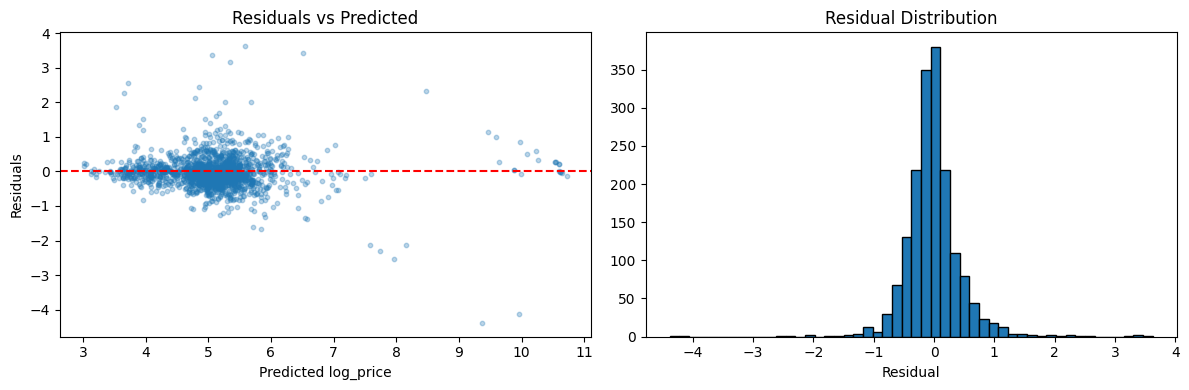

In [35]:
# Random Forest residuals
residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs predicted
axes[0].scatter(y_pred_rf, residuals, alpha=0.3, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted log_price')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

# Residual distribution
axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

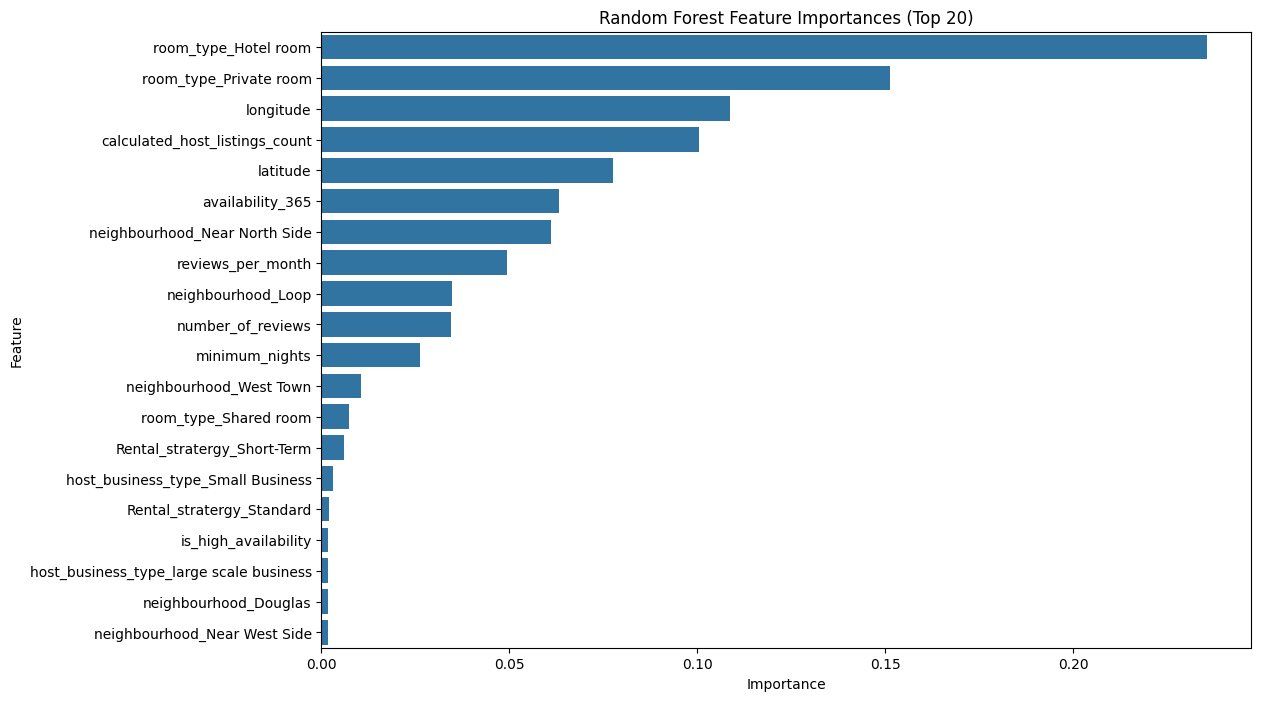

In [36]:
feature_importances = rf.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plotting top 20 features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('Random Forest Feature Importances (Top 20)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

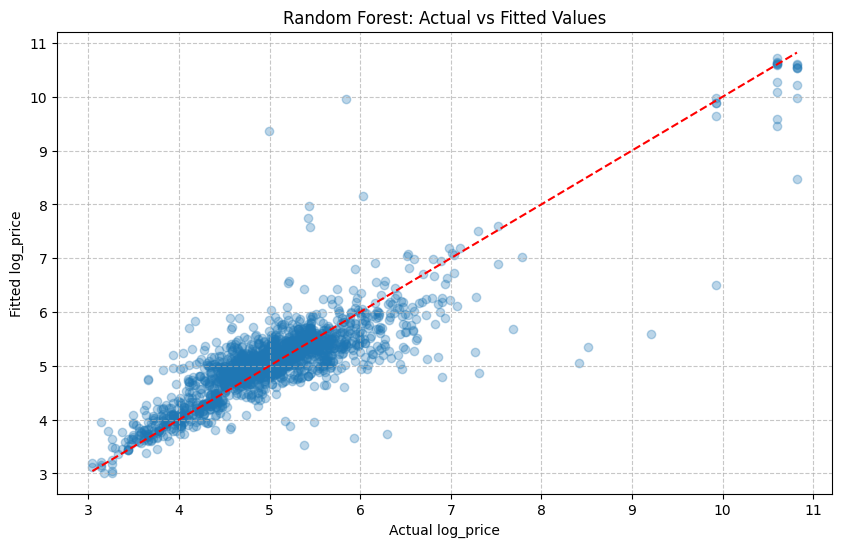

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('Actual log_price')
plt.ylabel('Fitted log_price')
plt.title('Random Forest: Actual vs Fitted Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()